# 🏦 Machine Learning Model Application on Loan Dataset

## Internship Project

### Developed by
**Niranjana B**

### Algorithm Used
**Logistic Regression**

### Development Environment
Anaconda Jupyter Notebook

### Objective
To build a Machine Learning model that predicts whether a loan application will be approved based on applicant information.

# Project Workflow


# 📌 1.Import Required Libraries

## 🎯 Objective

To import all the Python libraries required for data loading, preprocessing, visualization, model building, and evaluation.

In [2]:
# ==============================
# Import Required Libraries
# ==============================

# Data manipulation
import pandas as pd

# Numerical computations
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data preprocessing
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

# Splitting dataset
from sklearn.model_selection import train_test_split

# Machine Learning model
from sklearn.linear_model import LogisticRegression

# Model evaluation
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [3]:
# Display plots inside the notebook
%matplotlib inline


---
---


# 📌 2.Load Dataset

## 🎯 Objective

The objective of this phase is to:

Load the loan dataset into a Pandas DataFrame.
Understand how read_csv() works.
Verify that the dataset has loaded successfully.
Display the first few records for an initial inspection.

In [4]:
# Load the dataset
df = pd.read_csv("loan_data_set.csv")


### a.Display the first five records


In [5]:
# Display the first five rows
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


### b.Display the last five records

In [6]:
# Display the last five rows
df.tail()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y
613,LP002990,Female,No,0,Graduate,Yes,4583,0.0,133.0,360.0,0.0,Semiurban,N


---
---

# 📌 3.Dataset Understanding

## 🎯 Objective

The objective of this phase is to understand the structure, quality, and characteristics of the dataset before performing any preprocessing or Machine Learning tasks.

### 📘 a.Check Dataset Shape

In [7]:
# Check the number of rows and columns
df.shape

(614, 13)

### 📘 b.View Column Names

In [8]:
# Display all column names
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

### 📘 c.Check Data Types

In [9]:
# Display data types of all columns
df.dtypes

Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

### 📘 d.Dataset Information

In [10]:
# Display dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


### 📘 e.Statistical Summary

In [11]:
# Summary statistics
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [12]:
# includes a summary of categorical columns
df.describe(include="object")

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
count,614,601,611,599,614,582,614,614
unique,614,2,2,4,2,2,3,2
top,LP001002,Male,Yes,0,Graduate,No,Semiurban,Y
freq,1,489,398,345,480,500,233,422


In [13]:
df.describe(include="all")

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
count,614,601,611,599,614,582,614.000000,614.000000,592.000000,600.00000,564.000000,614,614
unique,614,2,2,4,2,2,NaN,NaN,NaN,NaN,NaN,3,2
top,LP001002,Male,Yes,0,Graduate,No,NaN,NaN,NaN,NaN,NaN,Semiurban,Y
freq,1,489,398,345,480,500,NaN,NaN,NaN,NaN,NaN,233,422
mean,NaN,NaN,NaN,NaN,NaN,NaN,5403.459283,1621.245798,146.412162,342.00000,0.842199,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,6109.041673,2926.248369,85.587325,65.12041,0.364878,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,150.000000,0.000000,9.000000,12.00000,0.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,2877.500000,0.000000,100.000000,360.00000,1.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,3812.500000,1188.500000,128.000000,360.00000,1.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,5795.000000,2297.250000,168.000000,360.00000,1.000000,NaN,NaN


### 📘 f.Check Missing Values

In [14]:
# Count missing values in each column
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

### 📘 g.Check Duplicate Records

In [15]:
# Count duplicate rows
df.duplicated().sum()

np.int64(0)

## Conclusion

The dataset has been thoroughly examined to understand its structure, data types, summary statistics, missing values, and duplicate records.

This analysis provides a clear understanding of the dataset and highlights the preprocessing steps required before building the Machine Learning model.

---
---

# 📌 4.Data Cleaning

## Objective

Data cleaning is the process of identifying and correcting errors or inconsistencies in a dataset before analysis or Machine Learning.

In this phase, we will handle missing values, remove duplicate records, and correct data types wherever necessary. Proper data cleaning improves data quality and helps build a more accurate and reliable Machine Learning model.

### 📘 a.Handle Missing Values

In [16]:
# Display the number of missing values in each column
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [17]:
# Fill missing values in categorical columns with the mode

categorical_columns = [
    'Gender',
    'Married',
    'Dependents',
    'Self_Employed',
    'Loan_Amount_Term',
    'Credit_History'
]

for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])
print(df[column])

0      1.0
1      1.0
2      1.0
3      1.0
4      1.0
      ... 
609    1.0
610    1.0
611    1.0
612    1.0
613    0.0
Name: Credit_History, Length: 614, dtype: float64


In [18]:
# Fill missing values in numerical columns with the median

numerical_columns = [
    'LoanAmount'
]

for column in numerical_columns:
    df[column] = df[column].fillna(df[column].median())
print(df[column])

0      128.0
1      128.0
2       66.0
3      120.0
4      141.0
       ...  
609     71.0
610     40.0
611    253.0
612    187.0
613    133.0
Name: LoanAmount, Length: 614, dtype: float64


In [19]:
# Verify missing values after imputation
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

### 📘 b.Remove Duplicate Records

In [20]:
# Count duplicate records
df.duplicated().sum()

np.int64(0)

In [21]:
# Remove duplicate rows
df.drop_duplicates(inplace=True)

In [22]:
# Verify duplicate removal
df.duplicated().sum()

np.int64(0)

### 📘 c.Data Type Correction

In [23]:
# Check data types after cleaning
df.dtypes

Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

## Conclusion

The dataset has been successfully cleaned by handling missing values, removing duplicate records, and verifying data types.

The data is now complete, consistent, and ready for exploratory data analysis and preprocessing in the next phase.

---
---

# 📌 5.Exploratory Data Analysis (EDA)

## 🎯 Objective

The objective of this phase is to explore the dataset, understand feature distributions, identify relationships with the target variable, and detect any potential issues that may affect Machine Learning model performance.

### 📘 a.Analyze the Target Variable

In [24]:
# Display the distribution of the target variable
df['Loan_Status'].value_counts()

Loan_Status
Y    422
N    192
Name: count, dtype: int64

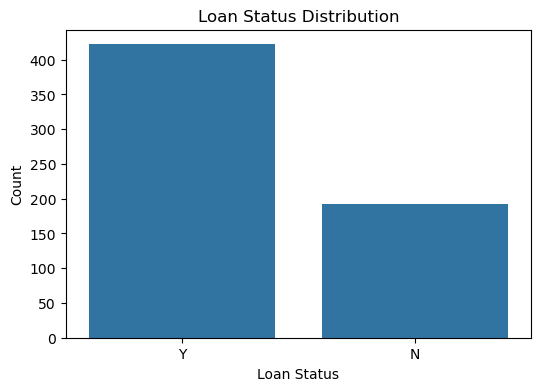

In [25]:
# Visualize the target variable
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Loan_Status')

plt.title("Loan Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Count")

plt.show()

### 📘 b.Distribution of Numerical Features

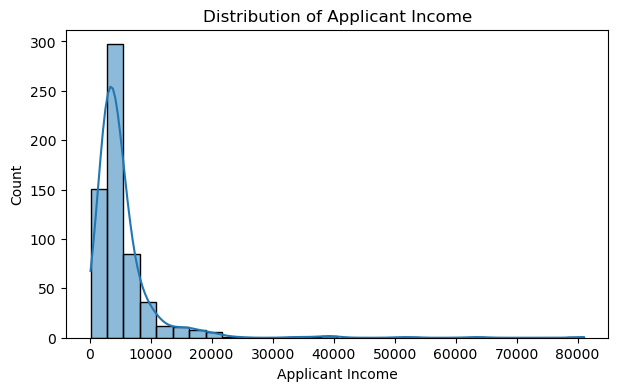

In [26]:
# Distribution of Applicant Income
plt.figure(figsize=(7, 4))
sns.histplot(df['ApplicantIncome'], bins=30, kde=True)

plt.title("Distribution of Applicant Income")
plt.xlabel("Applicant Income")

plt.show()

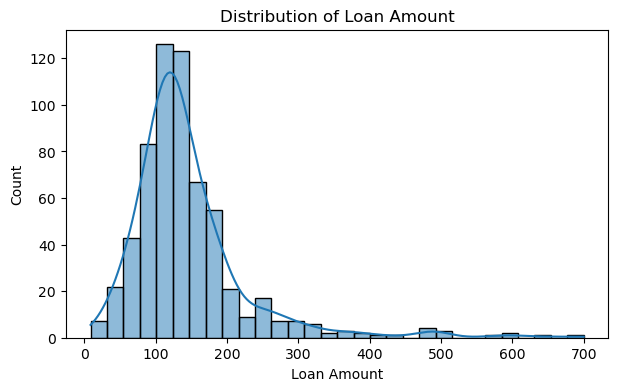

In [27]:
# Distribution of Loan Amount
plt.figure(figsize=(7, 4))
sns.histplot(df['LoanAmount'], bins=30, kde=True)

plt.title("Distribution of Loan Amount")
plt.xlabel("Loan Amount")

plt.show()

### 📘 c.Detect Outliers

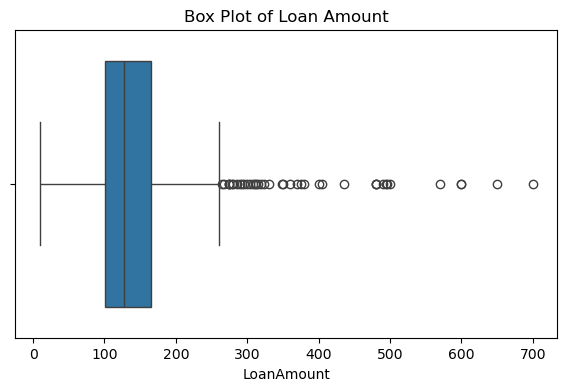

In [28]:
# Box plot for Loan Amount
plt.figure(figsize=(7, 4))
sns.boxplot(x=df['LoanAmount'])

plt.title("Box Plot of Loan Amount")

plt.show()

### d.Relationship Between Features and Target

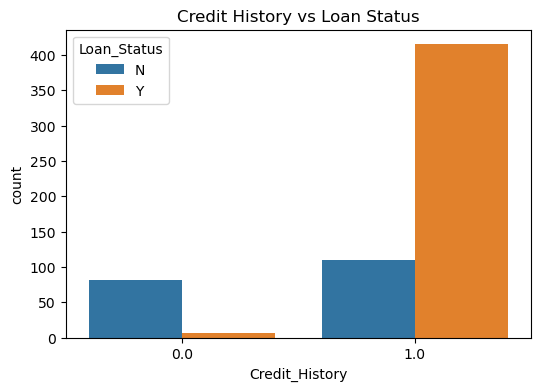

In [29]:
# Credit History vs Loan Status
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Credit_History', hue='Loan_Status')

plt.title("Credit History vs Loan Status")

plt.show()

### 📘 e.Correlation Analysis

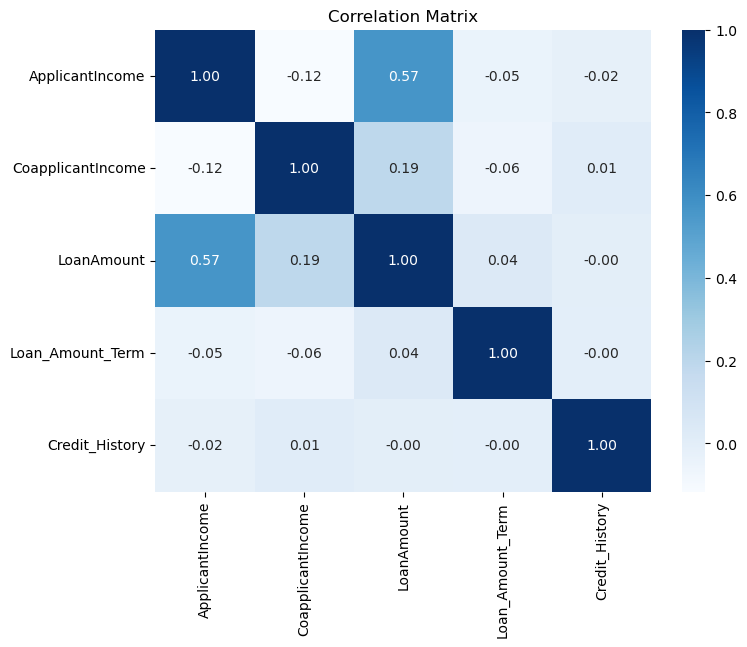

In [30]:
# Select only numerical columns
numerical_df = df.select_dtypes(include=['number'])

# Correlation matrix
correlation = numerical_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='Blues', fmt='.2f')

plt.title("Correlation Matrix")

plt.show()

## Conclusion

Exploratory Data Analysis provided valuable insights into the dataset before Machine Learning.

The analysis helped understand the distribution of the target variable, examine numerical feature distributions, detect potential outliers, explore relationships between important features and the target variable, and analyze correlations among numerical variables.

These findings support informed preprocessing decisions and improve the effectiveness of the Machine Learning model.

----
----

# 📌 6.Feature Engineering

## Objective

Feature Engineering is the process of creating new features or transforming existing features to improve the performance of a Machine Learning model.

Before creating any new feature, it is important to evaluate whether it provides additional useful information. Unnecessary feature engineering may increase model complexity without improving prediction accuracy.

In this project, we will examine whether feature engineering is required based on the characteristics of the loan dataset.

In [31]:
# Create a new feature: Total Income
df['TotalIncome'] = df['ApplicantIncome'] + df['CoapplicantIncome']

In [32]:
# Display the first five rows of the new feature
df[['ApplicantIncome',
    'CoapplicantIncome',
    'TotalIncome']].head()

,ApplicantIncome,CoapplicantIncome,TotalIncome
0,5849,0.0,5849.0
1,4583,1508.0,6091.0
2,3000,0.0,3000.0
3,2583,2358.0,4941.0
4,6000,0.0,6000.0


## 🌟 Conclusion

The loan dataset already contains informative features for predicting loan approval.

A meaningful feature, **TotalIncome**, was created by combining ApplicantIncome and CoapplicantIncome.

No additional feature engineering was performed because the remaining features already provide sufficient information for building the Logistic Regression model.

This approach keeps the model simple, interpretable, and aligned with the principle of creating only meaningful features.

---
---

# 📌 7.Encoding

## Objective

Machine Learning algorithms cannot directly process categorical (text) data. Therefore, categorical features must be converted into numerical values through a process called encoding.

In this phase, we will identify categorical columns, understand different encoding techniques, and apply the appropriate encoding method to prepare the dataset for Machine Learning.

### a.Identify the categorical columns

In [33]:
# Display categorical columns
df.select_dtypes(include='object').columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'Property_Area', 'Loan_Status'],
      dtype='object')

### b.Apply Label Encoding to Binary Columns

In [34]:
# Create a LabelEncoder object
label_encoder = LabelEncoder()

# Binary categorical columns
binary_columns = [
    'Gender',
    'Married',
    'Education',
    'Self_Employed',
    'Loan_Status'
]

# Apply Label Encoding
for column in binary_columns:
    df[column] = label_encoder.fit_transform(df[column])


### c.Apply One-Hot Encoding

In [35]:
# Apply One-Hot Encoding to Property_Area
df = pd.get_dummies(
    df,
    columns=['Property_Area'],
    drop_first=True,
    dtype=int
)

### d.Verify the encoding

In [36]:
# Display first five rows
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,TotalIncome,Property_Area_Semiurban,Property_Area_Urban
0,LP001002,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,1,5849.0,0,1
1,LP001003,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,6091.0,0,0
2,LP001005,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,1,3000.0,0,1
3,LP001006,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,1,4941.0,0,1
4,LP001008,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,1,6000.0,0,1


## Conclusion

Categorical variables were successfully converted into numerical form using appropriate encoding techniques.

Label Encoding was applied to binary categorical variables, while One-Hot Encoding was applied to the Property_Area feature to avoid introducing an artificial order.

The dataset is now ready for the feature scaling phase.

---
---

# 📌 8.Feature Scaling

## Objective

Feature Scaling is the process of transforming numerical features so that they have a similar range of values.

Many Machine Learning algorithms calculate distances or optimize mathematical functions during training. If the features have significantly different scales, variables with larger values may dominate the learning process.

In this phase, we will understand different scaling techniques and apply the most appropriate method to the loan dataset before training the Logistic Regression model.

### a.Identify the numerical feature columns

In [37]:
# Display numerical columns
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns
print("Numerical Columns:")
print(numerical_columns)

Numerical Columns:
Index(['Gender', 'Married', 'Education', 'Self_Employed', 'ApplicantIncome',
       'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History',
       'Loan_Status', 'TotalIncome', 'Property_Area_Semiurban',
       'Property_Area_Urban'],
      dtype='object')


### b.Create the scaler object

In [38]:
# Create a StandardScaler object
scaler = StandardScaler()

## Conclusion

Feature Scaling is an essential preprocessing step for Logistic Regression because it ensures that numerical features contribute proportionately during model training.

In this project, StandardScaler has been selected due to its suitability for Logistic Regression. The scaler object has been initialized and will be applied to the training and testing data after the train-test split.

---
---

# 📌 9.Feature Selection


## Objective

Feature Selection is the process of selecting the relevant input features (independent variables) and the target variable (dependent variable) for Machine Learning.

The selected features should contain meaningful information that helps the model learn patterns and make accurate predictions.

In this project, the target variable is **Loan_Status**, while the remaining relevant columns will be used as input features.

In [39]:
# Remove Loan_ID if it exists
if 'Loan_ID' in df.columns:
    df.drop('Loan_ID', axis=1, inplace=True)

### a.Create X and y

In [65]:
# Create independent variables (X)
X = df.drop(columns=['Loan_Status'])

# Create dependent variable (y)
y = df['Loan_Status']

### b.Verify the shapes of X and y

In [66]:
# Display the shape of X and y
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (614, 13)
Shape of y: (614,)


### c.Display the first few rows of X

In [67]:
# Display the first five rows of X
X.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,TotalIncome,Property_Area_Semiurban,Property_Area_Urban
0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,5849.0,0,1
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,6091.0,0,0
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,3000.0,0,1
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,4941.0,0,1
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,6000.0,0,1


### d.Display the first few values of y.

In [68]:
# Display the first five values of y
y.head()

0    1
1    0
2    1
3    1
4    1
Name: Loan_Status, dtype: int64

## Conclusion

The independent variables (X) and dependent variable (y) have been successfully identified and separated.

Any non-predictive identifier columns, if present, were excluded from the feature set.

The dataset is now properly prepared for splitting into training and testing sets in the next phase.

---
---

# 📌 10.Train-Test Split



## Objective

Before training a Machine Learning model, the dataset must be divided into two parts: a training set and a testing set.

The training set is used to teach the model patterns from historical data, while the testing set is used to evaluate how well the trained model performs on unseen data.

After splitting the data, feature scaling will be applied using StandardScaler to ensure that numerical features have a similar scale without introducing data leakage.

### a.Split the dataset

In [69]:
# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

### b.Verify the shapes

In [70]:
# Display the shape of training and testing datasets

print("X_train shape :", X_train.shape)
print("X_test shape  :", X_test.shape)
print("y_train shape :", y_train.shape)
print("y_test shape  :", y_test.shape)

X_train shape : (491, 13)
X_test shape  : (123, 13)
y_train shape : (491,)
y_test shape  : (123,)


### c.Identify only the numerical columns in X

In [71]:
# Identify numerical columns
numerical_features = X_train.select_dtypes(include=['int64', 'float64']).columns


### d.Apply StandardScaler

In [72]:
# Apply StandardScaler
X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test[numerical_features] = scaler.transform(X_test[numerical_features])

### e.Preview the scaled training data.

In [73]:
# Display the first five rows of the scaled training data

X_train.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,TotalIncome,Property_Area_Semiurban,Property_Area_Urban
83,0.483393,0.757442,-0.723275,-0.534173,-0.397516,0.083915,0.180667,1.355734,0.287611,0.407763,0.167302,1.253268,-0.692037
90,0.483393,0.757442,-0.723275,-0.534173,-0.397516,-0.429338,0.385430,-0.197609,0.287611,0.407763,-0.206402,1.253268,-0.692037
227,0.483393,0.757442,1.260681,-0.534173,-0.397516,0.126095,0.005831,0.718168,0.287611,0.407763,0.119652,1.253268,-0.692037
482,0.483393,0.757442,-0.723275,-0.534173,-0.397516,-0.576970,0.464185,-0.232385,0.287611,0.407763,-0.304046,1.253268,-0.692037
464,0.483393,-1.320234,-0.723275,-0.534173,-0.397516,-0.225522,-0.528127,-0.580149,0.287611,-2.452404,-0.470744,1.253268,-0.692037


## Conclusion

The dataset has been successfully split into training and testing sets.

StandardScaler was applied correctly by fitting the scaler on the training data and transforming both training and testing datasets.

The data is now fully prepared for training the Logistic Regression model.

---
---


# 📌 11.Machine Learning (Logistic Regression)


## Objective

Machine Learning is the process of enabling computers to learn patterns from historical data and make predictions on new data.

In this project, we use the Logistic Regression algorithm to predict whether a loan application is likely to be approved based on applicant information.

Before implementing the model, it is important to understand how Logistic Regression works, its advantages, limitations, and why it is suitable for this classification problem.

### a.create the Logistic Regression model

In [74]:
# Create the Logistic Regression model
model = LogisticRegression(random_state=42)

### b.Display the model configuration

In [75]:
# Display the model configuration
model

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


## Conclusion

The Logistic Regression algorithm was selected because the loan approval prediction problem is a binary classification task.

The model has been successfully initialized and is ready for training using the prepared training dataset.

---
---

# 📌 12.Model Training


## Objective

Model Training is the process of teaching a Machine Learning algorithm using historical data.

During this phase, the Logistic Regression model learns the relationship between the input features (X_train) and the target variable (y_train). Once training is complete, the model can predict loan approval for new applicants.

### a.Train the Logistic Regression model


In [76]:
# Train the Logistic Regression model
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


### b.Display the trained model

In [77]:
# Display the trained model
model

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [78]:
# Display model coefficients
coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_[0]
})

coefficients

,Feature,Coefficient
0,Gender,-0.013163
1,Married,0.298831
2,Dependents,0.127948
3,Education,-0.147554
4,Self_Employed,0.047557
5,ApplicantIncome,0.012205
6,CoapplicantIncome,-0.122323
7,LoanAmount,-0.160370
8,Loan_Amount_Term,0.040919
9,Credit_History,1.325441


## Conclusion

The Logistic Regression model was successfully trained using the training dataset.

The `fit()` method enabled the model to learn patterns from historical loan data by estimating the coefficients and intercept.

With training complete, the model is now prepared to make predictions on the testing dataset.

---
---

# 📌 13.Prediction


## Objective

Prediction is the process of using a trained Machine Learning model to estimate the target values for unseen data.

In this phase, the trained Logistic Regression model will predict the loan approval status for the testing dataset. These predictions will later be compared with the actual values to evaluate the model's performance.

### a.Generate predictions

In [80]:
# Predict the loan status for the testing data
y_pred = model.predict(X_test)

### b. Display the first 10 predictions 

In [81]:
# Display the first 10 predicted values
print("Predicted Loan Status:")
print(y_pred[:10])

Predicted Loan Status:
[1 1 1 1 1 1 1 1 1 1]


### c.Compare actual vs predicted values

In [85]:
# Compare actual and predicted values
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

comparison.head(10)

,Actual,Predicted
0,1,1
1,1,1
2,1,1
3,1,1
4,1,1
5,1,1
6,1,1
7,1,1
8,0,1
9,0,1


In [86]:
# Predict probabilities
y_prob = model.predict_proba(X_test)

# Display the first five probability predictions
pd.DataFrame(
    y_prob,
    columns=['Probability of Rejection', 'Probability of Approval']
).head()

,Probability of Rejection,Probability of Approval
0,0.112922,0.887078
1,0.093604,0.906396
2,0.183745,0.816255
3,0.291962,0.708038
4,0.145534,0.854466


## Conclusion

The trained Logistic Regression model was successfully used to predict loan approval for the testing dataset.

Both predicted class labels and prediction probabilities were generated. These results will be used in the next phase to evaluate the model using performance metrics such as Accuracy Score, Confusion Matrix, and Classification Report.

---
---

# 📌 14.Model Evaluation


## Objective

Model Evaluation is the process of measuring how well a trained Machine Learning model performs on unseen data.

In this phase, the Logistic Regression model will be evaluated using Accuracy Score, Confusion Matrix, and Classification Report.

These evaluation metrics help determine the reliability and effectiveness of the model.

### a.Calculate the accuracy score

In [97]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("=" * 40)
print(f"✅ Model Accuracy: {accuracy:.2%}")
print("=" * 40)

✅ Model Accuracy: 78.86%


### b.confusion matrix

In [94]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[18 25]
 [ 1 79]]


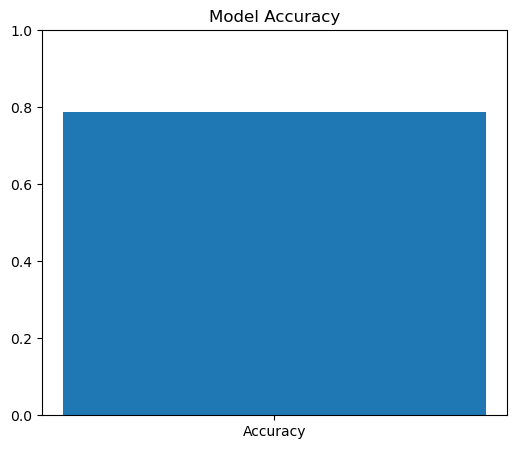

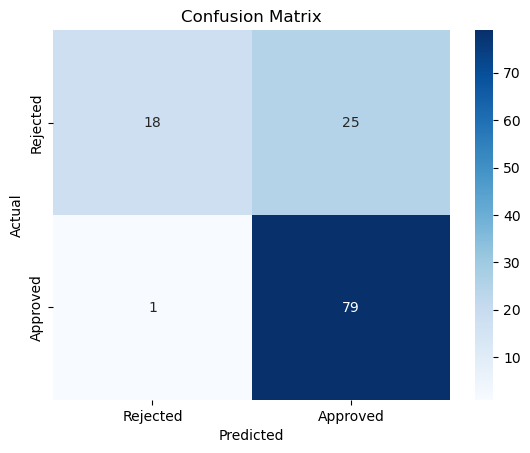

In [96]:
# Visualize the confusion matrix
plt.figure(figsize=(6, 5))

plt.bar(["Accuracy"], [accuracy])
plt.ylim(0, 1)
plt.title("Model Accuracy")
plt.show()

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Rejected', 'Approved'],
    yticklabels=['Rejected', 'Approved']
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### c.Classification Report

In [90]:
# Generate classification report
report = classification_report(y_test, y_pred)

print(report)

              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



## Conclusion

The Logistic Regression model was evaluated using Accuracy Score, Confusion Matrix, and Classification Report.

The evaluation metrics provide insights into the model's overall performance, prediction accuracy, and classification effectiveness.

These results help determine whether the model is reliable for predicting loan approval.

---
---

# 📌 15.Model Interpretation


## Objective

Model Interpretation is the process of analyzing the evaluation results of a Machine Learning model to understand its performance and reliability.

In this phase, the Accuracy Score, Confusion Matrix, and Classification Report are interpreted to determine how effectively the Logistic Regression model predicts loan approval.

## 📈 a. Interpretation of Accuracy Score

### Accuracy Summary

| Metric                     | Result              |
| -------------------------- | ------------------- |
| Machine Learning Algorithm | Logistic Regression |
| Accuracy Score             | **78.86%**          |
| Correct Predictions        | **97 out of 123**   |
| Overall Performance        | **Good**            |

### 🔍 Interpretation

* ✅ The Logistic Regression model achieved an **Accuracy Score of 78.86%** on the testing dataset.
* ✅ This indicates that the model correctly classified **97 out of 123** loan applications, which is approximately **79 out of every 100** applications.
* 📊 The achieved accuracy demonstrates **good overall predictive performance** for this binary classification problem.
* 💡 Although the model performs well overall, accuracy alone does not provide a complete evaluation. Therefore, additional metrics such as the **Confusion Matrix** and **Classification Report** were analyzed to gain deeper insights into the model's strengths and weaknesses.


## 📊 b. Interpretation of Confusion Matrix

### Confusion Matrix Summary

| Metric                |   Value |
| --------------------- | ------: |
| Total Test Samples    | **123** |
| Correct Predictions   |  **97** |
| Incorrect Predictions |  **26** |
| True Positives (TP)   |  **79** |
| True Negatives (TN)   |  **18** |
| False Positives (FP)  |  **25** |
| False Negatives (FN)  |   **1** |

### 🔍 Interpretation

* ✅ The model correctly classified **97 out of 123** loan applications.
* ✅ It successfully identified **79 approved loan applications**, misclassifying only **1 approved application** as rejected.
* ⚠️ The model incorrectly approved **25 rejected loan applications**, resulting in a relatively high number of **False Positives**.
* 📈 Overall, the model demonstrates good predictive performance and is particularly effective at identifying approved loan applications. Reducing False Positives would further improve its reliability in real-world loan approval decisions.


## 📑 c. Interpretation of Classification Report

### Performance Metrics

| Class            |  Precision |  Recall  | F1-Score |
| ---------------- | :--------: | :------: | :------: |
| Rejected (0)     |  **0.95**  | **0.42** | **0.58** |
| Approved (1)     |  **0.76**  | **0.99** | **0.86** |
| Overall Accuracy | **78.86%** |     —    |     —    |

### 🔍 Interpretation

* ✅ The model achieved an overall **Accuracy Score of 78.86%**.
* 🎯 For the **Approved** class, the model achieved a **Recall of 99%**, successfully identifying almost all approved loan applications.
* ✔️ For the **Rejected** class, the **Precision of 95%** indicates that rejected predictions were usually correct. However, the **Recall of 42%** shows that many rejected applications were incorrectly predicted as approved.
* 📈 Overall, the model performs well in predicting approved loan applications but requires improvement in identifying rejected applications to reduce false approvals.


## 🌟 d. Overall Model Reliability

### Performance Overview

| Evaluation Metric    | Result                                      |
| -------------------- | ------------------------------------------- |
| Accuracy Score       | **78.86%**                                  |
| Best Performance     | Approved Loan Prediction (Recall = **99%**) |
| Area for Improvement | Rejected Loan Prediction (Recall = **42%**) |
| Overall Assessment   | **Good Baseline Model**                     |

### 🔍 Interpretation

The evaluation results indicate that the Logistic Regression model provides **good overall predictive performance** for loan approval prediction.

The model correctly classified approximately **79 out of every 100** loan applications and demonstrated excellent capability in identifying approved loan applications. However, its lower Recall for rejected applications suggests that some rejected loans were incorrectly classified as approved.

Overall, the model serves as a **reliable baseline classifier**, while additional feature engineering, hyperparameter tuning, or more advanced Machine Learning algorithms could further improve its performance.


## ⚠️ e. Limitations

Although the Logistic Regression model achieved satisfactory performance, it has several limitations:

| Limitation                  | Description                                                                                                           |
| --------------------------- | --------------------------------------------------------------------------------------------------------------------- |
| 📈 Linear Assumption        | Logistic Regression assumes a linear relationship between the input features and the log-odds of the target variable. |
| ❌ False Positives           | The model incorrectly approved several rejected loan applications, indicating a higher number of False Positives.     |
| 🔄 Non-linear Relationships | It may not effectively capture complex non-linear patterns present in the dataset.                                    |
| 📊 Data Dependency          | Model performance depends on data quality, feature selection, and preprocessing techniques.                           |
| 🤖 Model Complexity         | More advanced Machine Learning algorithms may achieve higher predictive performance for this dataset.                 |


## 🚀 f. Possible Improvements

The performance of the loan approval prediction model can be enhanced through the following improvements:

| Improvement                     | Benefit                                                                                                                                    |
| ------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------ |
| 📂 Collect More Data            | Increase the diversity and quality of training data to improve model generalization.                                                       |
| ⚙️ Advanced Feature Engineering | Create more informative features that better represent applicant characteristics.                                                          |
| 🎯 Hyperparameter Tuning        | Optimize the Logistic Regression model for improved predictive performance.                                                                |
| 🤖 Compare Multiple Algorithms  | Evaluate models such as Decision Tree, Random Forest, Support Vector Machine (SVM), and XGBoost to identify the best-performing algorithm. |
| 🔄 Cross-Validation             | Perform k-fold cross-validation to obtain a more reliable estimate of model performance.                                                   |
| 📌 Feature Selection            | Select the most influential features to improve accuracy and reduce unnecessary complexity.                                                |


## Conclusion

The Logistic Regression model successfully predicted loan approval using the processed dataset.

After performing data cleaning, feature engineering, encoding, feature scaling, feature selection, and train-test splitting, the model was trained and evaluated using standard classification metrics.

The model achieved an **Accuracy Score of 78.86%**, demonstrating good overall predictive performance. It was highly effective in identifying approved loan applications but showed comparatively lower performance in identifying rejected applications.

Overall, this project successfully demonstrated a complete end-to-end Machine Learning workflow and highlighted the importance of data preprocessing, model evaluation, and result interpretation in building reliable predictive models.

---
---

# 📌 16.Final Conclusion


## 📋 Project Summary

This project successfully developed a **Machine Learning model for Loan Approval Prediction** using the **Logistic Regression** algorithm.

The loan dataset was imported, explored, and cleaned by handling missing values, removing duplicates, and correcting data inconsistencies. Exploratory Data Analysis (EDA) was performed to understand the characteristics of the data and identify the factors influencing loan approval.

To prepare the dataset for Machine Learning, feature engineering was applied by creating the **TotalIncome** feature. Categorical variables were encoded into numerical values, and numerical features were standardized using **StandardScaler** to ensure consistent feature scaling.

The processed dataset was divided into training and testing datasets using an **80:20 ratio**. A Logistic Regression model was trained using the training data and evaluated on unseen testing data.

The model achieved an **Accuracy Score of 78.86%**, demonstrating good predictive performance. Additional evaluation using the **Confusion Matrix** and **Classification Report** showed that the model performed exceptionally well in identifying approved loan applications while indicating opportunities to improve the detection of rejected applications.

Overall, the project successfully demonstrated an end-to-end Machine Learning workflow, from data preprocessing to model evaluation and interpretation.


## Key Learnings

| Category               | Skills Acquired                                   |
| ---------------------- | ------------------------------------------------- |
| 📂 Data Handling       | Dataset loading, cleaning, preprocessing          |
| 📊 Data Analysis       | EDA, feature understanding                        |
| ⚙️ Feature Engineering | TotalIncome creation                              |
| 🔤 Data Transformation | Encoding categorical variables                    |
| 📏 Feature Scaling     | StandardScaler                                    |
| 🤖 Machine Learning    | Logistic Regression                               |
| 📈 Model Evaluation    | Accuracy, Confusion Matrix, Classification Report |
| 💡 Interpretation      | Understanding Precision, Recall and F1-Score      |


## 📊 Final Performance Summary

| Metric           | Result                           |
| ---------------- | -------------------------------- |
| Algorithm        | Logistic Regression              |
| Train-Test Split | 80 : 20                          |
| Accuracy         | **78.86%**                       |
| Precision        | 0.95 (Rejected), 0.76 (Approved) |
| Recall           | 0.42 (Rejected), 0.99 (Approved) |
| F1-Score         | 0.58 (Rejected), 0.86 (Approved) |


## 🚀 Future Scope

- Improve feature engineering.
- Perform hyperparameter tuning.
- Compare multiple classification algorithms.
- Apply Cross Validation.
- Deploy the model using Flask or Streamlit.

### ✅ Final Conclusion

This project successfully implemented a complete Machine Learning pipeline for predicting loan approval using Logistic Regression.

From data preprocessing and feature engineering to model training and evaluation, each stage followed standard Machine Learning practices. The model achieved an **Accuracy Score of 78.86%**, demonstrating good predictive capability for this binary classification problem.

The evaluation results indicate that the model performs particularly well in identifying approved loan applications while highlighting opportunities to improve the prediction of rejected applications. Overall, this project provided valuable practical experience in data preprocessing, feature engineering, model development, evaluation, and interpretation, forming a strong foundation for solving real-world Machine Learning problems.


---
---

---
#                                             **Project Completed Successfully**